In [44]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [45]:
class mlp(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=784, out_features=64, bias=False)
        self.layer2 = nn.Linear(in_features=64, out_features=10, bias=False)
        self.relu = nn.ReLU()
    def forward(self,x):
        return self.layer2(self.relu(self.layer1(x)))

In [46]:
loaded_data = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = loaded_data.data, loaded_data.target
X = torch.from_numpy(X)
X = X.to(torch.float32)
X /= 255.0
T = torch.from_numpy(np.eye(10)[y.astype(int)])

In [47]:
np.random.seed(42)
num_epoch = 1000
num_data = X.shape[0]
split = int(num_data * .8)
shuffle = np.random.permutation(num_data)
X_train, T_train = X[shuffle[:split]], T[shuffle[:split]]
X_test, T_test = X[shuffle[split:]], T[shuffle[split:]]
lr = 0.1
snapshot_delay = 100
test_labels = np.argmax(T_test, axis=1)
num_test = X_test.shape[0]
num_train = X_train.shape[0]

In [48]:
model = mlp()
lossfn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1)

In [49]:
accuracyfn = lambda preds, T, num: torch.sum(torch.argmax(preds, dim=1) == torch.argmax(T, dim=1))/num

In [50]:
for epoch in range(num_epoch):
    # forward
    preds = model.forward(X_train)
    # backward
    loss = lossfn(preds, T_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    if epoch%snapshot_delay == 0:
        model.eval()
        with torch.inference_mode():
            test_preds = model.forward(X_test)
            test_loss = lossfn(test_preds, T_test, )
            acc = accuracyfn(preds, T_train, num_train)
            test_acc = accuracyfn(test_preds, T_test, num_test)
            print(f"epoch: {epoch} loss: {loss} test loss: {test_loss} acc: {acc} test_acc: {test_acc}")


epoch: 0 loss: 2.29767857755082 test loss: 2.1810940798606193 acc: 0.09055357426404953 test_acc: 0.507357120513916
epoch: 100 loss: 0.2514467793072718 test loss: 0.25384932144977124 acc: 0.9264107346534729 test_acc: 0.9247857332229614
epoch: 200 loss: 0.17846302091199193 test loss: 0.18942578307678565 acc: 0.9483928680419922 test_acc: 0.944428563117981
epoch: 300 loss: 0.14527829767434575 test loss: 0.16162725649522736 acc: 0.958017885684967 test_acc: 0.9533571600914001
epoch: 400 loss: 0.12247904757433799 test loss: 0.14319863951625508 acc: 0.9650178551673889 test_acc: 0.9576428532600403
epoch: 500 loss: 0.10679342789132086 test loss: 0.13171615010131932 acc: 0.9703035950660706 test_acc: 0.9607856869697571
epoch: 600 loss: 0.09524340429162396 test loss: 0.12399445473967564 acc: 0.9736250042915344 test_acc: 0.9624999761581421
epoch: 700 loss: 0.08596310715042606 test loss: 0.11808027909578618 acc: 0.9763928651809692 test_acc: 0.9645000100135803
epoch: 800 loss: 0.0784387062323332 test 

In [51]:
pred_labels = torch.argmax(model.forward(X_test), dim = 1)

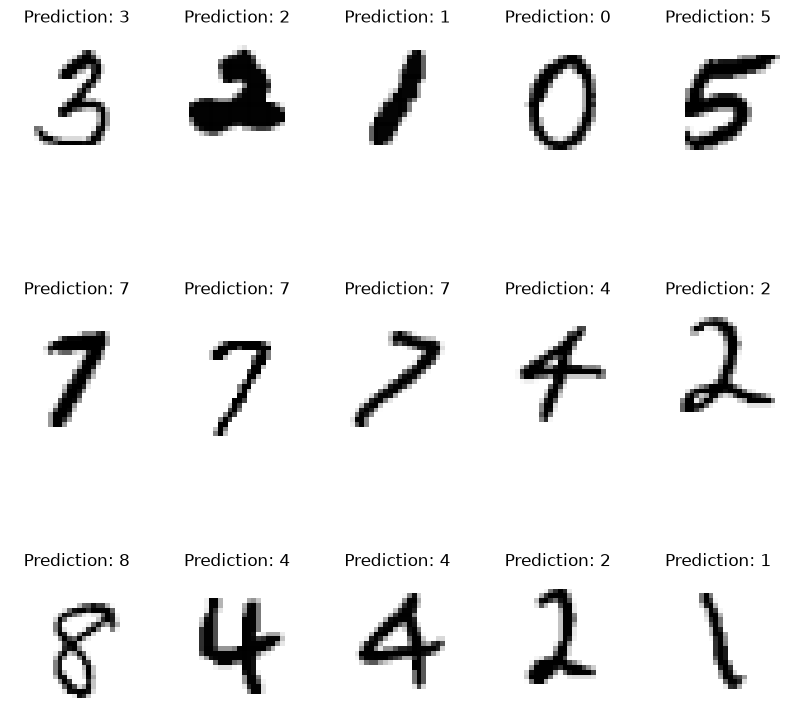

In [52]:
fig, ax = plt.subplots(3,5, figsize=[10, 10])
for i in range(15):
    ax[i//5, i%5].imshow(np.reshape(X_test[i], (28, 28)), cmap='binary')
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_title(f"Prediction: {pred_labels[i]}")